# Project Env & Importing Libraries

In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
PROCESSED_DIR = f"{DATA_DIR}/processed"
ANALYSIS_OUTPUT_DIR = f"{DATA_DIR}/analysis"


HEALTHCARE_PATH = f"{PROCESSED_DIR}/Casablanca_Healthcare.gpkg"
TRANSPORT_PATH = f"{PROCESSED_DIR}/Casablanca_Transport_Stops.gpkg"
DISTRICTS_PATH = f"{PROCESSED_DIR}/Casablanca_Districts.gpkg"
POPULATION_PATH = f"{PROCESSED_DIR}/population_by_districts.gpkg"

CRS_METRIC      = "EPSG:26191"   # Morocco zone 1 (metres) — for accurate distance
CRS_GEO         = "EPSG:4326"    # WGS84 for web maps

import os
os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True)

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN
import folium
from sklearn.neighbors import NearestNeighbors
from folium.plugins import MarkerCluster, HeatMap
import ast
import matplotlib.patheffects as pe
from matplotlib.ticker import FuncFormatter


# Import Data

In [3]:
# Load files
hospitals = gpd.read_file(HEALTHCARE_PATH)
stops = gpd.read_file(TRANSPORT_PATH)
districts = gpd.read_file(DISTRICTS_PATH)
population = gpd.read_file(POPULATION_PATH)


print(f'Healthcare facilities : {len(hospitals):,} rows | CRS: {hospitals.crs}')
print(f'Transport stops       : {len(stops):,}  rows | CRS: {stops.crs}')
print(f'Districts             : {len(districts):,}  rows | CRS: {districts.crs}')
print(f'Population            : {len(population):,}  rows | CRS: {population.crs}')

Healthcare facilities : 84 rows | CRS: EPSG:4326
Transport stops       : 1,463  rows | CRS: EPSG:4326
Districts             : 34  rows | CRS: EPSG:4326
Population            : 34  rows | CRS: EPSG:4326


# Clean and standardize

- Ensure datasets share same CRS
- Parse ```Lines``` and ```mode``` columns in transport dataset 

In [6]:
# Reproject to metric CRS for distance calculations
hospitals = hospitals.to_crs(epsg=3857)
stops  = stops.to_crs(epsg=3857)
districts = districts.to_crs(epsg=3857)
population = population.to_crs(epsg=3857)

In [7]:
# Parse transport mode & lines columns which are stored as strings like "['casabus', 'tram']"
def safe_parse_list(val):
    """Safely parse a string like "['casabus', 'tram']" into a Python list"""
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else [result]
    except:
        return [str(val)]

stops['mode_list']  = stops['mode'].apply(safe_parse_list)
stops['lines_list'] = stops['Lines'].apply(safe_parse_list)

# Primary mode (first element)
stops['primary_mode'] = stops['mode_list'].apply(lambda x: x[0] if x else 'unknown')
stops['num_lines']    = stops['lines_list'].apply(len)

print('Transport modes:')
print(stops['mode'].value_counts())

print('Primary Transport modes:')
print(stops['primary_mode'].value_counts())

print(f'\nAvg lines per stop: {stops["num_lines"].mean():.2f}')

Transport modes:
mode
['casabus']              1311
['tram']                   96
['busway']                 41
['tram', 'casabus']         8
['casabus', 'tram']         6
['busway', 'casabus']       1
Name: count, dtype: int64
Primary Transport modes:
primary_mode
casabus    1317
tram        104
busway       42
Name: count, dtype: int64

Avg lines per stop: 1.97


# Exploratory Data Analysis (EDA)

In [4]:
# Quick peek at each dataset
print('=== HEALTHCARE ===')
display(hospitals.head(2))
print('\n=== TRANSPORT STOPS ===')
display(stops.head(2))
print('\n=== DISTRICTS ===')
display(districts.head(2))
print('\n=== POPULATION ===')
display(population.head(2))

=== HEALTHCARE ===


,name,latitude,longitude,geometry
0,clinique badr,33.594870,-7.641098,POINT (-7.6411 33.59487)
1,hôpital sidi othmane,33.558542,-7.573301,POINT (-7.5733 33.55854)



=== TRANSPORT STOPS ===


,cluster_id,stop_name,Lines,mode,longitude,latitude,geometry
0,0,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633955,33.592059,POINT (-7.63395 33.59206)
1,1,112 Boulevard D'Anfa,"['L09E', 'L084', 'L050', 'L013']",['casabus'],-7.633524,33.592137,POINT (-7.63352 33.59214)



=== DISTRICTS ===


,district,commune,commune_type_encoded,geometry
0,Bouskoura,Bouskoura,0,"MULTIPOLYGON (((-7.68792 33.41272, -7.68806 33..."
1,Bouskoura,Dar Bouazza,0,"MULTIPOLYGON (((-7.76684 33.45884, -7.77442 33..."



=== POPULATION ===


,commune,population,geometry
0,tit mellil,56019,"MULTIPOLYGON (((-7.48923 33.52544, -7.49853 33..."
1,mediouna,29972,"MULTIPOLYGON (((-7.52353 33.45134, -7.52288 33..."


In [5]:
# Data types and null counts
print('--- Healthcare info ---')
hospitals.info()
print('\n--- Stops info ---')
stops.info()
print('\n--- Districts info ---')
districts.info()
print('\n--- Population info ---')
population.info()

--- Healthcare info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   name       84 non-null     object  
 1   latitude   84 non-null     float64 
 2   longitude  84 non-null     float64 
 3   geometry   84 non-null     geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 2.8+ KB

--- Stops info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1463 entries, 0 to 1462
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   cluster_id  1463 non-null   int64   
 1   stop_name   1463 non-null   object  
 2   Lines       1463 non-null   object  
 3   mode        1463 non-null   object  
 4   longitude   1463 non-null   float64 
 5   latitude    1463 non-null   float64 
 6   geometry    1463 non-null   geometry
dtypes: float64(2), geometry(1), int64(1), 

### Spatial Visualization

In [10]:
# ── Geographic extent / bounding box comparison ──────────────────────────
print('Healthcare bounding box:')
print(f'  Lat: {hospitals.latitude.min():.4f} → {hospitals.latitude.max():.4f}')
print(f'  Lon: {hospitals.longitude.min():.4f} → {hospitals.longitude.max():.4f}')

print('\nTransport bounding box:')
print(f'  Lat: {stops.latitude.min():.4f} → {stops.latitude.max():.4f}')
print(f'  Lon: {stops.longitude.min():.4f} → {stops.longitude.max():.4f}')

Healthcare bounding box:
  Lat: 33.5198 → 33.6124
  Lon: -7.6873 → -7.4835

Transport bounding box:
  Lat: 33.3717 → 33.7088
  Lon: -7.8853 → -7.3305


#### Distribution of healthcare facilities and transport stops

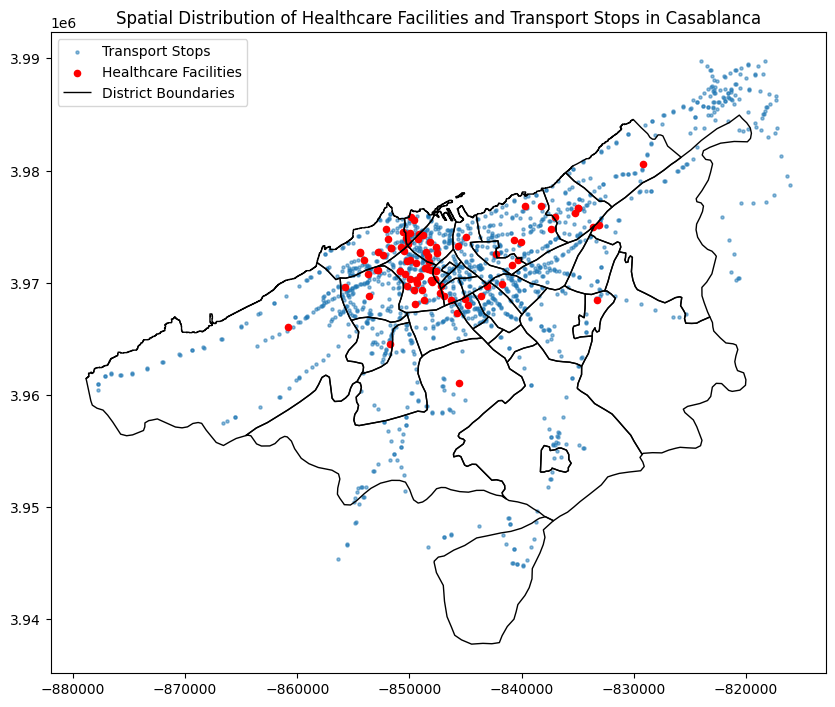

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

stops.plot(ax=ax, markersize=5, alpha=0.5, label="Transport Stops")
hospitals.plot(ax=ax, color="red", markersize=20, label="Healthcare Facilities")
districts.boundary.plot(ax=ax, color="black", linewidth=1, label="District Boundaries")

plt.legend()
plt.title("Spatial Distribution of Healthcare Facilities and Transport Stops in Casablanca")
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/SpatialVisualization.png', bbox_inches='tight')
plt.show()

#### Population by Districts 

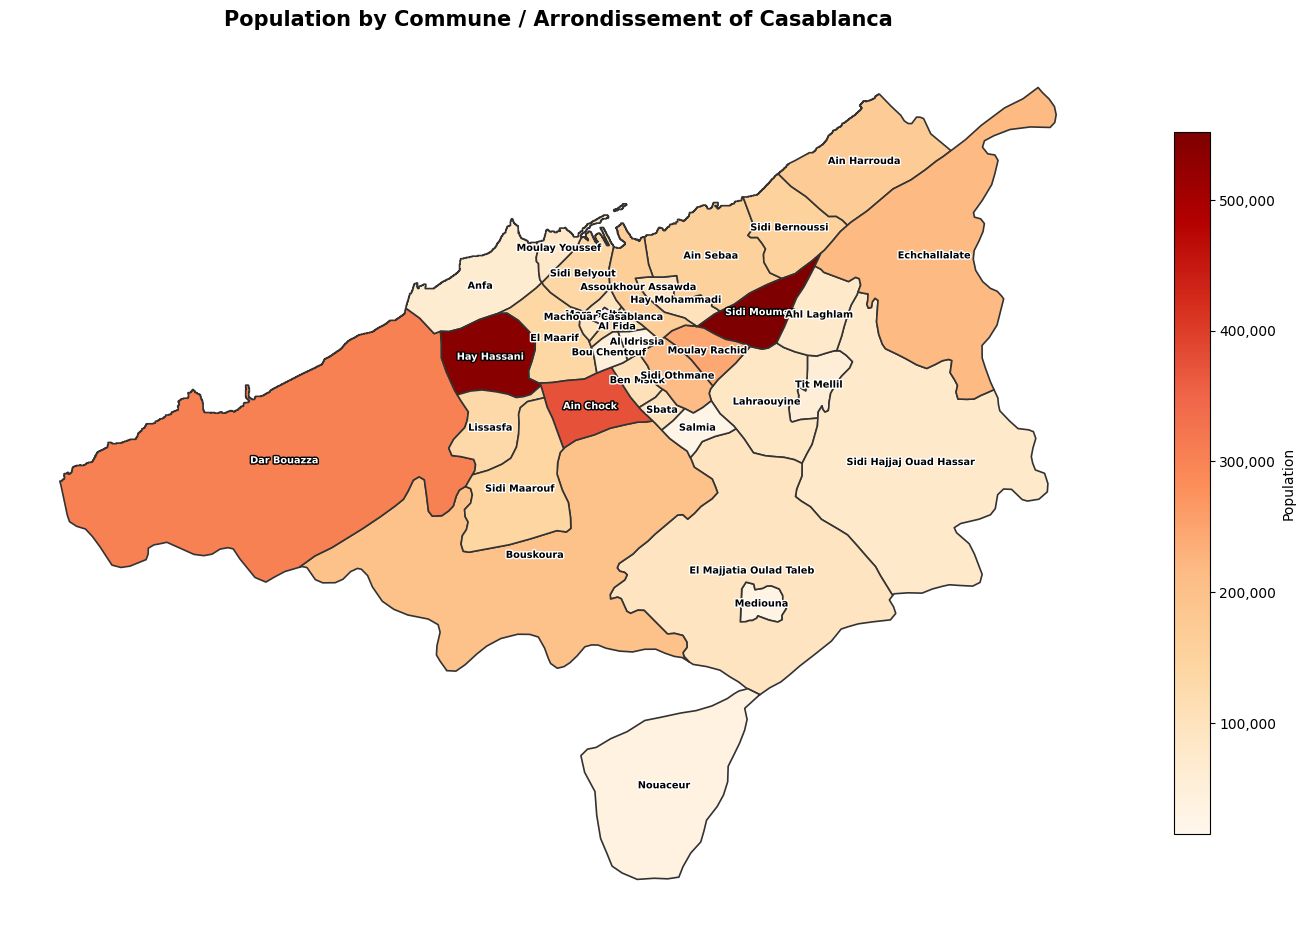

### Transport mode distribution

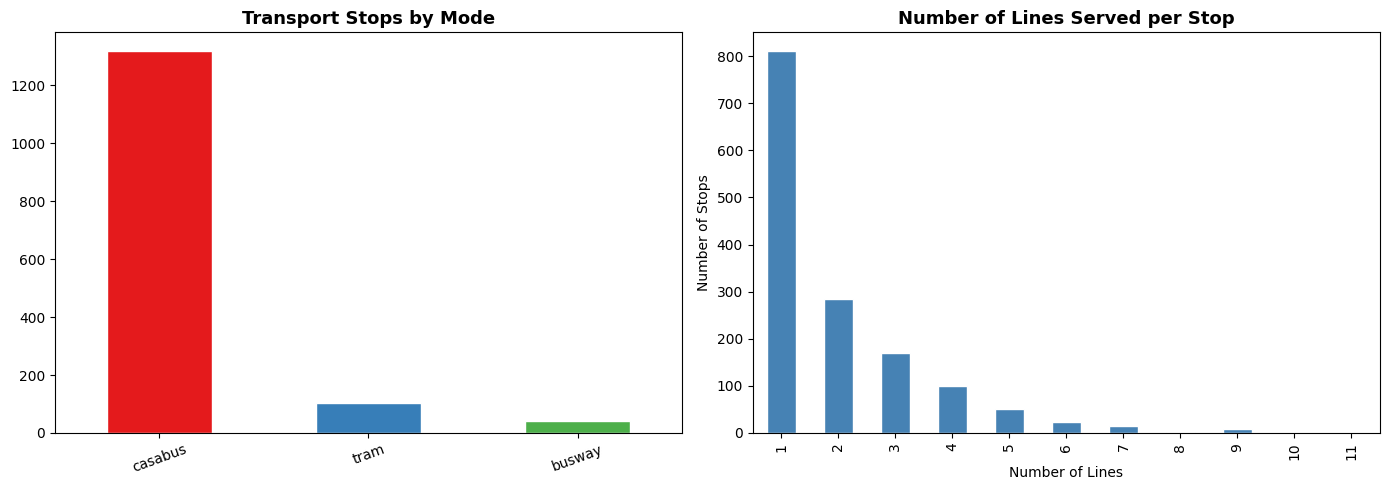


📊 Summary:
  Stops with only 1 line : 810 (55.4%)
  Stops with 3+ lines    : 368 (25.2%)


In [ ]:
# ── Transport mode distribution & lines per stop ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mode counts
mode_counts = stops['primary_mode'].value_counts()
mode_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set1'), edgecolor='white')
axes[0].set_title('Transport Stops by Mode', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Lines per stop
stops['num_lines'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Number of Lines Served per Stop', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Lines')
axes[1].set_ylabel('Number of Stops')

plt.tight_layout()
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/transport_eda.png', bbox_inches='tight')
plt.show()

print(f'\nSummary:')
print(f'  Stops with only 1 line : {(stops["num_lines"]==1).sum()} ({(stops["num_lines"]==1).mean()*100:.1f}%)')
print(f'  Stops with 3+ lines    : {(stops["num_lines"]>=3).sum()} ({(stops["num_lines"]>=3).mean()*100:.1f}%)')

The results indicate a clear **spatial imbalance** in both healthcare and transport supply across Casablanca.

- Public transport is also **unevenly distributed**: total stops are high overall, but clustered in a subset of districts (notably **Bouskoura**, **Ain Sebaa**, **Hay Hassani**, **Anfa**, and **El Maarif**).
- By mode, the network is strongly **bus-dominant** (**1359 bus/busway stops vs 104 tram stops**), meaning tram accessibility is restricted to fewer corridors and districts.

Overall, these patterns suggest that geographic access to healthcare by transit is likely unequal.

# Population Density per District

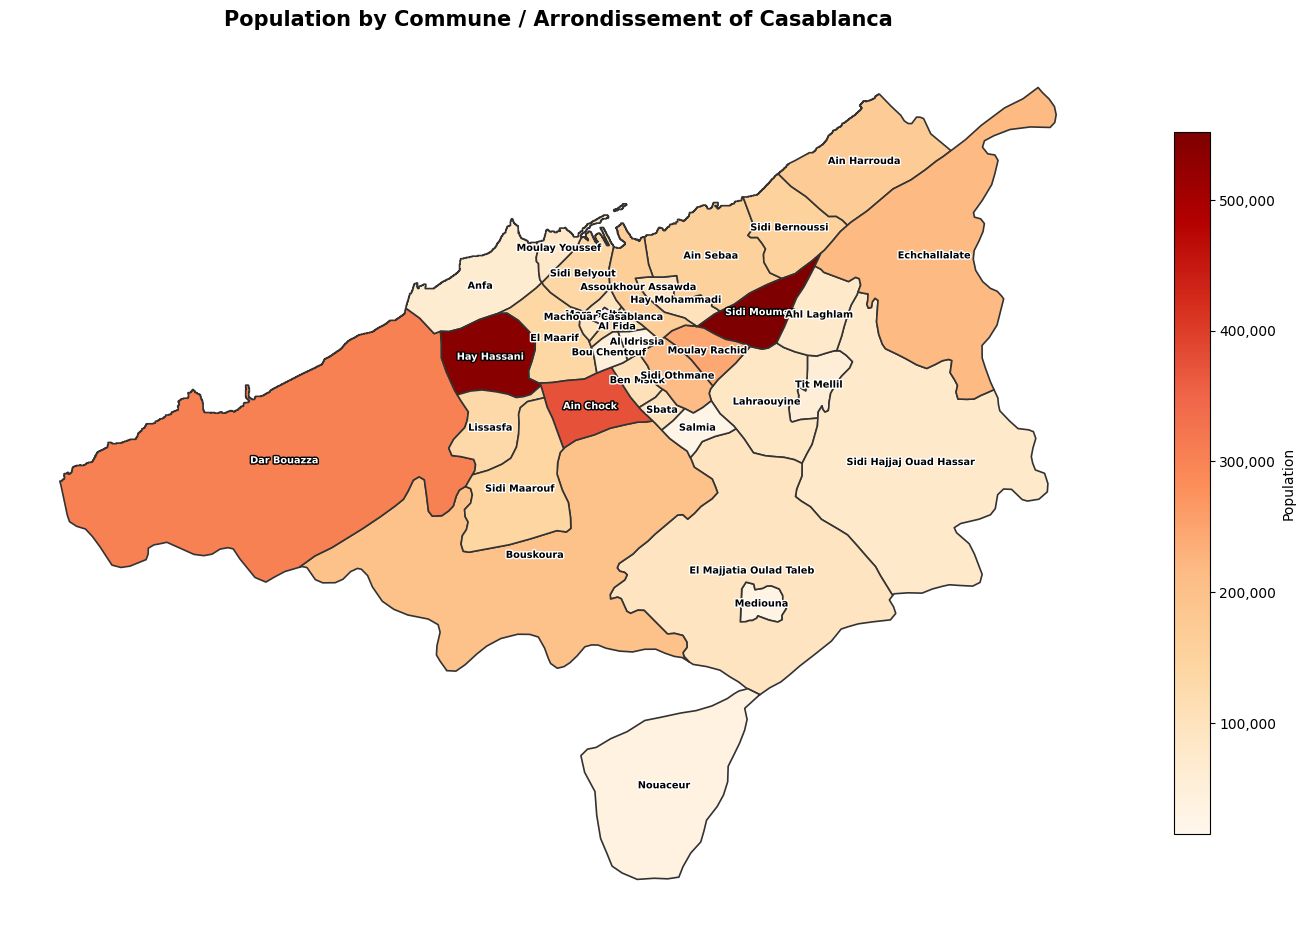

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12)) 

# Choropleth map of population by district
population.plot( 
    column="population", 
    cmap="OrRd", 
    linewidth=1.2,          
    edgecolor="#333333",    
    legend=True,
    legend_kwds={
        "label": "Population",
        "orientation": "vertical",
        "shrink": 0.6,
        "format": FuncFormatter(lambda x, _: f"{int(x):,}")  # comma-formatted ticks
    },
    ax=ax 
) 

# Add labels for each district
for idx, row in population.iterrows():
    pop = row["population"]
    name = row["commune"].title()  # capitalize each word

    # pick label color based on background darkness
    text_color = "white" if pop > 300_000 else "black"

    ax.annotate(
        name,
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=7,
        color=text_color,
        fontweight='bold',
        path_effects=[                          # white halo for contrast
            pe.withStroke(linewidth=2, foreground="white" if text_color == "black" else "black")
        ]
    )


ax.set_title(
    "Population by Commune / Arrondissement of Casablanca",
    fontsize=15,
    fontweight='bold',
    pad=16
)
ax.axis("off")

plt.tight_layout()
plt.savefig(f"{ANALYSIS_OUTPUT_DIR}/population_by_districts.png", dpi=300, bbox_inches='tight')
plt.show()

# Healthcare facilities per district

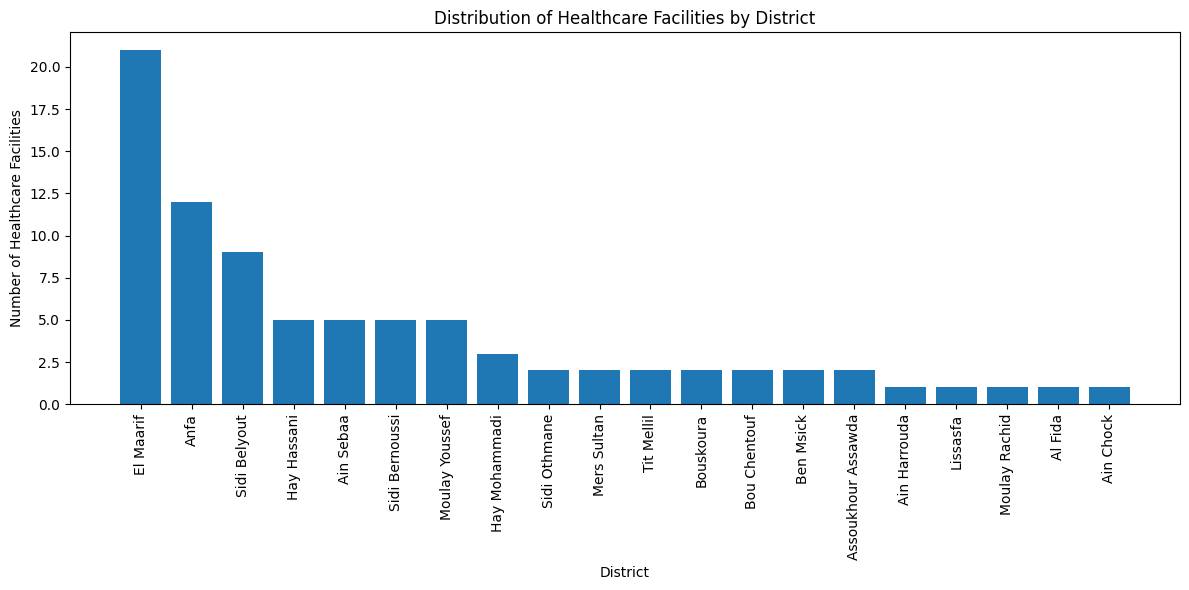

In [50]:
# Join healthcare facilities with districts to count number of facilities per district
healthcare_with_districts = gpd.sjoin(hospitals, districts, how="left", predicate="within")

# Count healthcare facilities per district
healthcare_counts = (
    healthcare_with_districts.groupby("district")
    .size()
    .reset_index(name="num_healthcare")
)

# Sort values in descending order
healthcare_counts = healthcare_counts.sort_values(by="num_healthcare", ascending=False)

# Plot Bar Chart of Healthcare Facilities by District
plt.figure(figsize=(12, 6))

plt.bar(healthcare_counts["district"], healthcare_counts["num_healthcare"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Healthcare Facilities")
plt.title("Distribution of Healthcare Facilities by District")

plt.tight_layout()
plt.show()

The distribution of healthcare facilities is clearly **uneven across Casablanca**.

- A total of **84 facilities** were mapped.
- Healthcare services are concentrated in a few central districts:
    - **El Maarif (21)**
    - **Anfa (12)**
    - **Sidi Belyout (9)**
- These three districts alone account for roughly **half of all facilities**.

At the same time, many districts have only **1–2 facilities**, and several districts show **no recorded facilities** in this dataset.  

# Transport Stops Per District

To explore the spatial distribution of public transport infrastructure, we computed the total number of stops (including both bus and tramway) within each district.

Each stop was assigned to a district using a spatial join, and counts were aggregated to identify areas with higher concentrations of transport services. The results are visualized in the bar chart below.

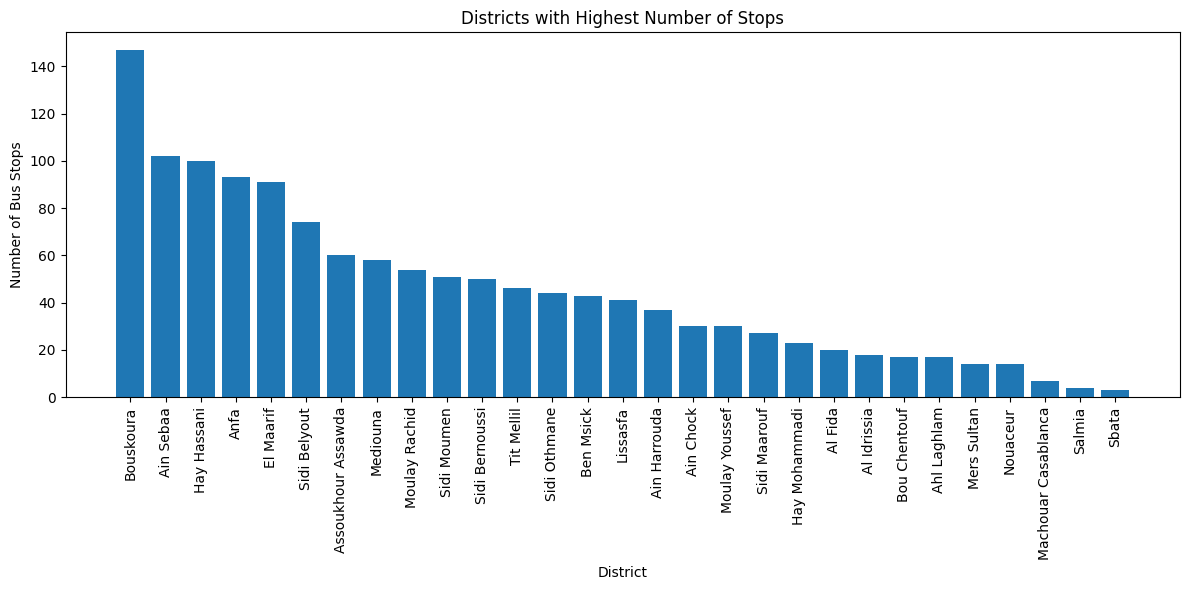

In [33]:
# Spatial join to assign each stop to a district
stops_with_districts = gpd.sjoin(stops, districts, how="left", predicate="within")

# Count stops per district
stops_count = stops_with_districts.groupby("district").size().reset_index(name="num_stops")

stops_count = stops_count.sort_values(by="num_stops", ascending=False)
plt.figure(figsize=(12, 6))

plt.bar(stops_count["district"], stops_count["num_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Bus Stops")
plt.title("Districts with Highest Number of Stops")

plt.tight_layout()
plt.show()


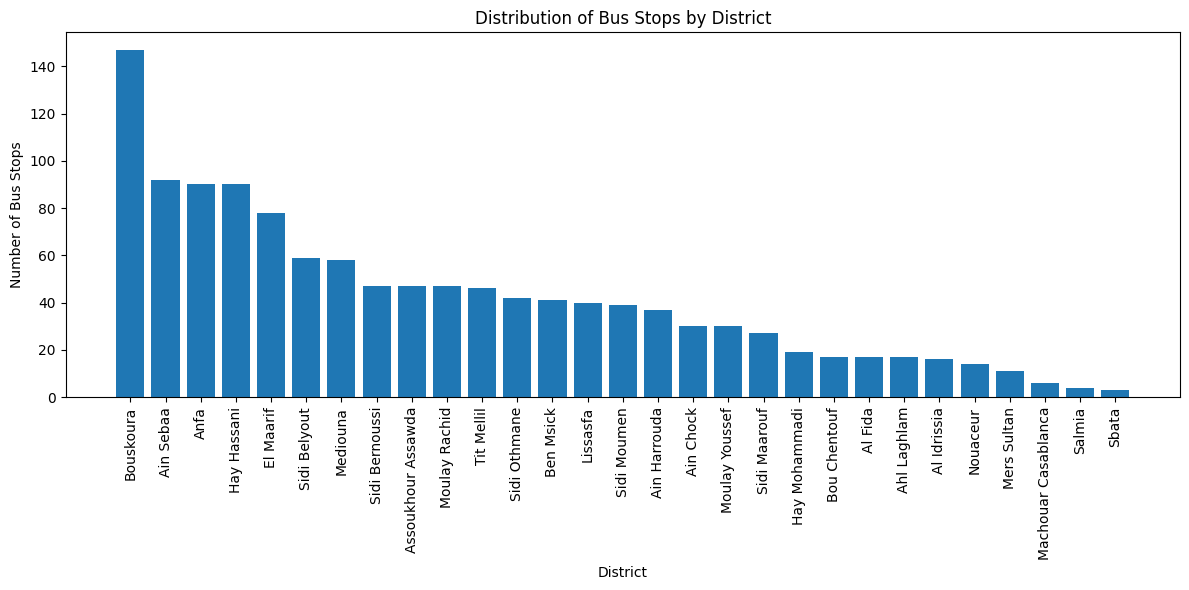

In [40]:
bus_stops = stops_with_districts[
    stops_with_districts["primary_mode"].isin(["casabus", "busway"])
]

bus_counts = (
    bus_stops.groupby("district")
    .size()
    .reset_index(name="num_bus_stops")
    .sort_values(by="num_bus_stops", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(bus_counts["district"], bus_counts["num_bus_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Bus Stops")
plt.title("Distribution of Bus Stops by District")

plt.tight_layout()
plt.show()

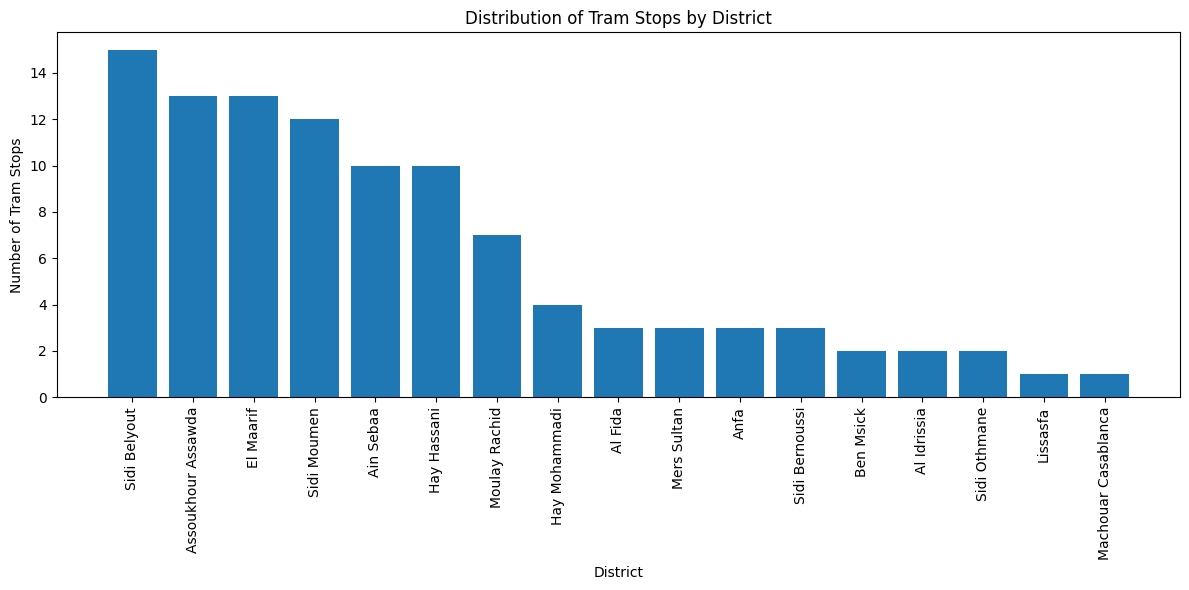

In [35]:
tram_stops = stops_with_districts[
    stops_with_districts["primary_mode"] == "tram"
]

tram_counts = (
    tram_stops.groupby("district")
    .size()
    .reset_index(name="num_tram_stops")
    .sort_values(by="num_tram_stops", ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(tram_counts["district"], tram_counts["num_tram_stops"])

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Number of Tram Stops")
plt.title("Distribution of Tram Stops by District")

plt.tight_layout()
plt.show()

The district level analysis shows a **strong spatial imbalance** in transport infrastructure across Casablanca.

- A total of **1,463 stops** were mapped, but only **29 districts** contain stops in the current aggregation.
- Stop coverage is concentrated in a few districts, with **Bouskoura (147)**, followed by **Ain Sebaa (102)**, **Hay Hassani (100)**, **Anfa (93)**, and **El Maarif (91)**.
- At the lower end, districts such as **Sbata (3)** and **Salmia (4)** appear comparatively under-served.

 **By transport mode**
- **Bus/busway stops** dominate the network and largely drive the overall ranking (again led by Bouskoura, Ain Sebaa, Anfa, Hay Hassani, and El Maarif).
- **Tram stops** are much fewer and concentrated in a smaller set of districts, especially **Sidi Belyout**, **Assoukhour Assawda**, **El Maarif**, and **Sidi Moumen**.


# Population density and healthcare facilities distribution

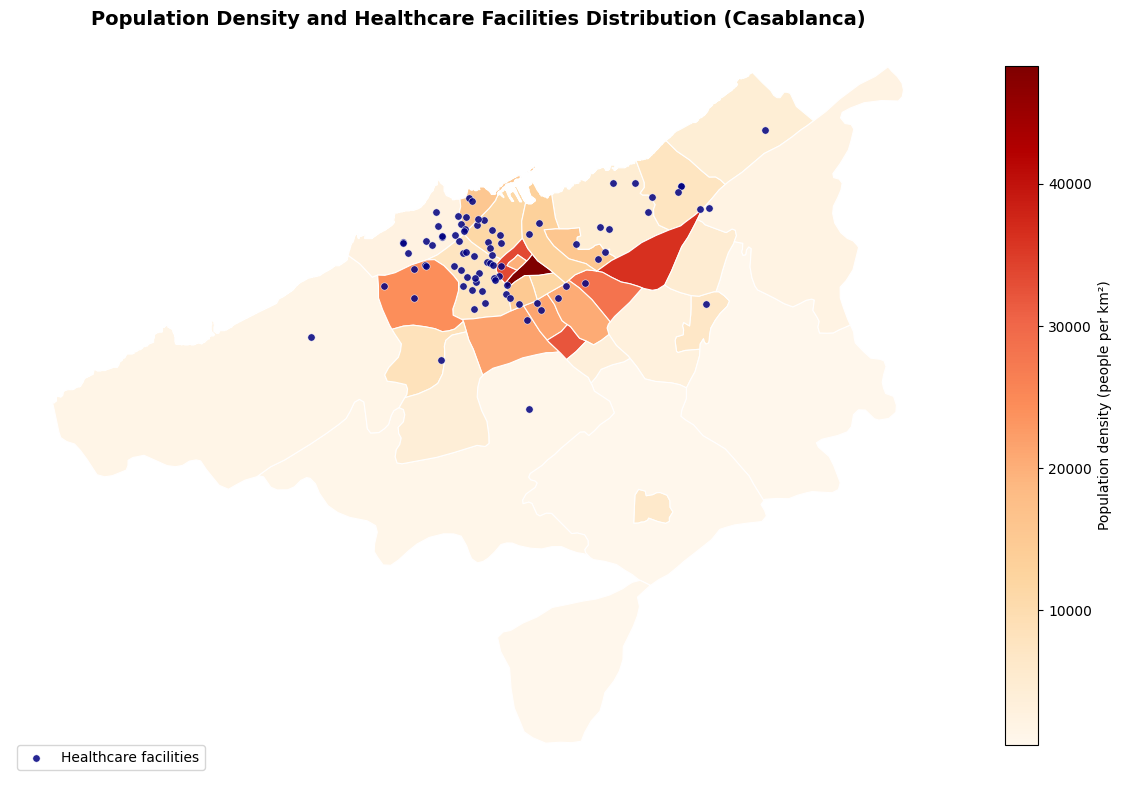

In [52]:
# Population density map + healthcare facilities overlay

# Ensure same CRS before plotting
if population.crs != hospitals.crs:
	pop_map = population.to_crs(hospitals.crs)

# Compute population density (people per km²)
pop_map["area_km2"] = pop_map.geometry.area / 1e6
pop_map["pop_density_km2"] = pop_map["population"] / pop_map["area_km2"]

fig, ax = plt.subplots(figsize=(12, 10))

# Choropleth: population density
pop_map.plot(
	column="pop_density_km2",
	cmap="OrRd",
	linewidth=0.8,
	edgecolor="white",
	legend=True,
	legend_kwds={"label": "Population density (people per km²)", "shrink": 0.7},
	ax=ax
)

# Overlay healthcare facilities
hospitals.plot(
	ax=ax,
	color="navy",
	markersize=28,
	alpha=0.85,
	edgecolor="white",
	linewidth=0.4,
	label="Healthcare facilities"
)

ax.set_title("Population Density and Healthcare Facilities Distribution (Casablanca)", fontsize=14, fontweight="bold")
ax.axis("off")
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig(f"{ANALYSIS_OUTPUT_DIR}/population_density_healthcare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The overlay suggests a **mismatch between demand and service location** in Casablanca.

- Healthcare facilities appear concentrated in a limited set of central districts (notably **El Maarif**, **Anfa**, and **Sidi Belyout**).
- Several districts with large populations (e.g., **Sidi Moumen**, **Hay Hassani**, **Ain Chock**) show comparatively fewer facilities relative to their population size.
- Peripheral communes with lower density generally have sparse healthcare coverage, which may increase travel burdens.

Overall, the pattern indicates potential **spatial inequity** in healthcare access: areas with higher population pressure do not always coincide with higher facility availability.  

# Spatial Analysis

## Nearest Transport Stop to Each Healthcare facility

**Why?** This tells us how walkable each healthcare facility is from a transit stop — a key measure of transit-based accessibility.

**Method:** We use a `cKDTree` (spatial index) for fast nearest-neighbor lookup. We first project to a metric CRS (`EPSG:32629` — UTM zone 29N, appropriate for Morocco) so distances are in **meters**, not degrees.

In [ ]:
# Project to metric CRS EPSG:32629 for accurate distance measurement 

hospitals_m = hospitals.to_crs(epsg=32629)
stops_m  = stops.to_crs(epsg=32629)

# Extract coordinates as numpy arrays
hospitals_coords = np.array([(geom.x, geom.y) for geom in hospitals_m.geometry])
stops_coords  = np.array([(geom.x, geom.y) for geom in stops_m.geometry])

# Build spatial index on stops
tree = cKDTree(stops_coords)

# Query: for each healthcare facility, find the nearest stop
distances, indices = tree.query(hospitals_coords, k=1)

hospitals['nearest_stop_dist_m'] = distances
hospitals['nearest_stop_name']   = stops.iloc[indices]['stop_name'].values
hospitals['nearest_stop_mode']   = stops.iloc[indices]['primary_mode'].values

print('Nearest stop computed for all healthcare facilities')
print(f'\nDistance to nearest stop (meters):')
print(hospitals['nearest_stop_dist_m'].describe().round(1))

Nearest stop computed for all healthcare facilities

Distance to nearest stop (meters):
count     82.0
mean     164.6
std       97.4
min       29.4
25%       94.9
50%      139.2
75%      221.9
max      483.1
Name: nearest_stop_dist_m, dtype: float64


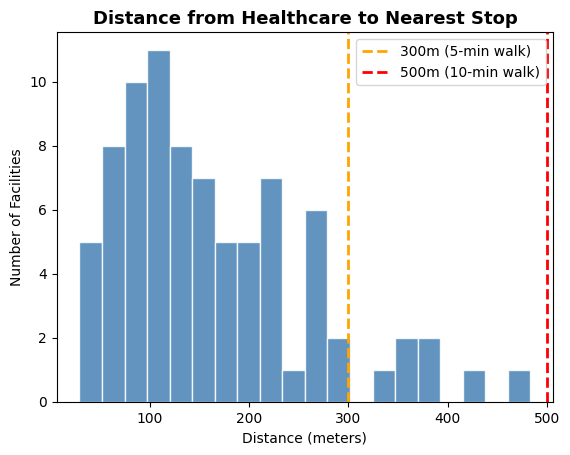


🏥 Facilities within 300m of a stop : 75/82 (91.5%)
🏥 Facilities within 500m of a stop : 82/82 (100.0%)


In [15]:
# ── Visualize nearest stop distance distribution ──────────────────────────────
# Histogram
plt.hist(hospitals['nearest_stop_dist_m'], bins=20, color='steelblue',
             edgecolor='white', alpha=0.85)
plt.axvline(300, color='orange', linestyle='--', lw=2, label='300m (5-min walk)')
plt.axvline(500, color='red',    linestyle='--', lw=2, label='500m (10-min walk)')
plt.title('Distance from Healthcare to Nearest Stop', fontsize=13, fontweight='bold')
plt.xlabel('Distance (meters)')
plt.ylabel('Number of Facilities')
plt.legend()


plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/nearest_stop_distance.png', bbox_inches='tight')
plt.show()

# Summary
within_300 = (hospitals['nearest_stop_dist_m'] <= 300).sum()
within_500 = (hospitals['nearest_stop_dist_m'] <= 500).sum()
print(f'\n🏥 Facilities within 300m of a stop : {within_300}/{len(hospitals)} ({within_300/len(hospitals)*100:.1f}%)')
print(f'🏥 Facilities within 500m of a stop : {within_500}/{len(hospitals)} ({within_500/len(hospitals)*100:.1f}%)')

### Stop Density Around Healthcare Facilities

**Why?** A single nearby stop is better than nothing, but a cluster of stops means more route options and better connectivity. Here we count how many stops fall within walking distance (500m) of each facility.

In [16]:
# ── Count stops within 500m of each facility ─────────────────────────────────
RADIUS_M = 500

# Use query_ball_point to get ALL stops within radius
indices_within = tree.query_ball_point(hospitals_coords, r=RADIUS_M)
hospitals['stops_within_500m'] = [len(idx) for idx in indices_within]

# Also compute unique lines accessible
def count_unique_lines(stop_indices):
    lines = set()
    for i in stop_indices:
        lines.update(stops.iloc[i]['lines_list'])
    return len(lines)

hospitals['unique_lines_500m'] = [count_unique_lines(idx) for idx in indices_within]

print('Stops within 500m per facility:')
print(hospitals['stops_within_500m'].describe().round(1))
print('\nUnique transit lines within 500m:')
print(hospitals['unique_lines_500m'].describe().round(1))

Stops within 500m per facility:
count    82.0
mean      6.4
std       3.0
min       1.0
25%       4.0
50%       6.0
75%       8.0
max      13.0
Name: stops_within_500m, dtype: float64

Unique transit lines within 500m:
count    82.0
mean      6.4
std       3.7
min       1.0
25%       3.0
50%       6.5
75%       8.0
max      18.0
Name: unique_lines_500m, dtype: float64


In [17]:
# ── Top & bottom facilities by accessibility ──────────────────────────────────
cols = ['name', 'stops_within_500m', 'unique_lines_500m', 'nearest_stop_dist_m']

print('=== Most accessible facilities (most stops nearby) ===')
display(hospitals.nlargest(10, 'stops_within_500m')[cols])

print('\n=== Least accessible facilities (fewest stops nearby) ===')
display(hospitals.nsmallest(10, 'stops_within_500m')[cols].sort_values('stops_within_500m', ascending=False))

=== Most accessible facilities (most stops nearby) ===


,name,stops_within_500m,unique_lines_500m,nearest_stop_dist_m
34,clinique maarif,13,6,226.982360
38,centre hospitalier universitaire ibn rochd,13,11,290.486461
26,clinique les iris,12,8,222.905425
30,clinique rachidi,12,17,212.121314
1,hôpital sidi othmane,11,9,99.298145
16,clinique mutualiste cnops,11,18,143.778950
24,clinique maghreb,11,7,155.439087
25,clinique al massira,11,8,94.660328
27,akdital oasis,11,10,156.855463
40,polyclinique cnss ziraoui,11,7,265.736698



=== Least accessible facilities (fewest stops nearby) ===


,name,stops_within_500m,unique_lines_500m,nearest_stop_dist_m
4,avicenne clinique des spécialistes,3,1,362.313015
11,clinique elmouahidin,3,2,95.615794
13,clinique andalouss,3,1,36.036898
21,clinique longchamps,3,1,176.900444
15,clinique firdaous,2,7,208.201990
39,clinique dar salam,2,6,97.659048
35,clinique socrate,1,3,291.312230
66,clinique adoha,1,5,192.055356
68,clinique al amal,1,3,96.144792
81,hôpital mohammed v,1,1,483.148097


### 4c. Healthcare Facility Density Around each stop

**Why?** From the transit user's perspective — which stops give access to the most healthcare options? This helps identify key transit-health hubs.

In [18]:
# ── Build a KD-tree on healthcare and query from stops ────────────────────────
hospitals_tree = cKDTree(hospitals_coords)
stops_coords_arr = np.array([(geom.x, geom.y) for geom in stops_m.geometry])

hospitals_within_idx = hospitals_tree.query_ball_point(stops_coords_arr, r=RADIUS_M)
stops['health_facilities_500m'] = [len(idx) for idx in hospitals_within_idx]

print('Facilities accessible within 500m from each stop:')
print(stops['health_facilities_500m'].describe().round(2))

print('\n=== Top transit stops for healthcare access ===')
top_stops = stops.nlargest(10, 'health_facilities_500m')[['stop_name', 'primary_mode', 'num_lines', 'health_facilities_500m']]
display(top_stops)

Facilities accessible within 500m from each stop:
count    1463.00
mean        0.36
std         0.75
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         4.00
Name: health_facilities_500m, dtype: float64

=== Top transit stops for healthcare access ===


,stop_name,primary_mode,num_lines,health_facilities_500m
243,BOULEVARD MOHAMED SIJILMASSI,casabus,1,4
557,GENDARMERIE MY IDRISS I,casabus,6,4
694,LES ARENES,casabus,4,4
734,LYCEE LAHLOU,casabus,6,4
740,LYCEE MOULAY ABDELLAH,casabus,6,4
1033,RESIDENCE SHEMSI,casabus,1,4
1109,RUE NORMANDIE,casabus,3,4
0,112 Boulevard D'Anfa,casabus,4,3
50,ANGLE BD ANFA/BDZERKTOUNI,casabus,3,3
107,ARRET CMC,casabus,1,3


In [19]:
def classify_access(n):
    if n == 0:
        return "No access"
    elif n <= 2:
        return "Low"
    elif n <= 5:
        return "Medium"
    else:
        return "High"

stops['access_tier'] = stops['health_facilities_500m'].apply(classify_access)

stops['access_tier'].value_counts()

access_tier
No access    1131
Low           297
Medium         35
Name: count, dtype: int64

<Axes: title={'center': 'Transit Stop Healthcare Accessibility'}, xlabel='access_tier'>

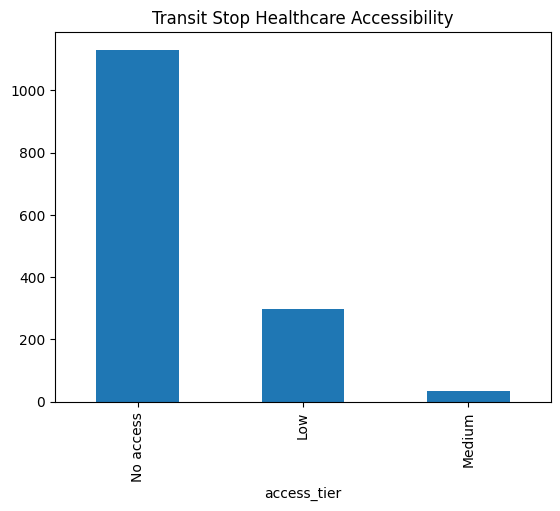

In [20]:
stops['access_tier'].value_counts().plot(kind='bar', title='Transit Stop Healthcare Accessibility')

### 4d. Accessibility Score

**Why?** We combine multiple factors into a single 0–100 score to rank facilities:
- Distance to nearest stop (lower = better)
- Number of stops within 500m (higher = better)
- Number of unique lines within 500m (higher = better)

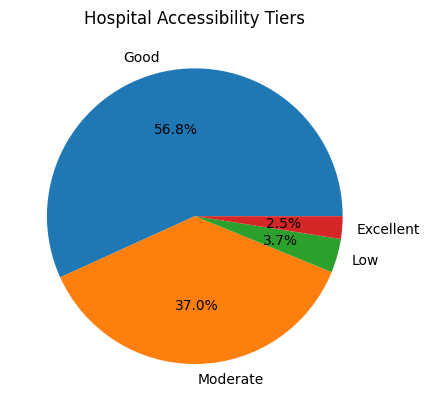

Accessibility score distribution:
access_tier
Good         46
Moderate     30
Low           3
Excellent     2
Name: count, dtype: int64


,name,accessibility_score,access_tier
16,clinique mutualiste cnops,84.085156,Excellent
30,clinique rachidi,79.506231,Excellent
1,hôpital sidi othmane,74.771252,Good
56,hopital sidi othmane,74.103053,Good
25,clinique al massira,73.709529,Good
61,clinique ain chock,73.497751,Good
27,akdital oasis,71.167637,Good
64,polyclinique cnss hay hassani,70.697345,Good
44,clinique sidi othmane,70.115682,Good
3,clinique abdelmoumen,69.720694,Good


In [27]:
from sklearn.preprocessing import MinMaxScaler

# Components to use in score
score_df = hospitals[['nearest_stop_dist_m', 'stops_within_500m', 'unique_lines_500m']].copy()

scaler = MinMaxScaler()
normalized = scaler.fit_transform(score_df)

# Invert distance (closer = better → higher score)
dist_score  = 1 - normalized[:, 0]    # inverted
stops_score = normalized[:, 1]
lines_score = normalized[:, 2]

# Weighted composite score
hospitals['accessibility_score'] = (
    0.40 * dist_score +
    0.35 * stops_score +
    0.25 * lines_score
) * 100  # scale to 0–100

# Categorize
hospitals['access_tier'] = pd.cut(
    hospitals['accessibility_score'],
    bins=[0, 25, 50, 75, 100],
    labels=['Low', 'Moderate', 'Good', 'Excellent']
)

tier_counts = hospitals['access_tier'].value_counts()
plt.figure()
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%')
plt.title('Hospital Accessibility Tiers')
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/Hospital Accessibility Tiers.png', bbox_inches='tight')
plt.show()


print('Accessibility score distribution:')
print(tier_counts)
display(hospitals[['name', 'accessibility_score', 'access_tier']].sort_values('accessibility_score', ascending=False).head(10))

In [28]:
display(hospitals[['name', 'accessibility_score', 'access_tier']].sort_values('accessibility_score', ascending=False).tail())

,name,accessibility_score,access_tier
78,clinique al wafaa,27.366979,Moderate
35,clinique socrate,19.853260,Low
4,avicenne clinique des spécialistes,16.486049,Low
32,clinique val d'anfa,12.878454,Low
81,hôpital mohammed v,0.000000,NaN


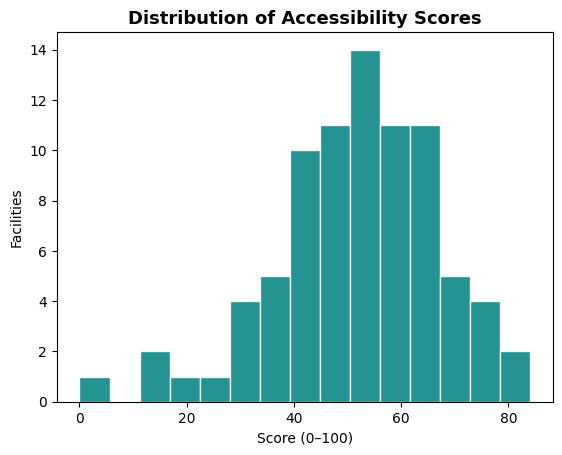

In [52]:
# ── Visualize scores ──────────────────────────────────────────────────────────
# Score distribution
hospitals['accessibility_score'].plot(kind='hist', bins=15,
                                    color='teal', edgecolor='white', alpha=0.85)
plt.title('Distribution of Accessibility Scores', fontsize=13, fontweight='bold')
plt.xlabel('Score (0–100)')
plt.ylabel('Facilities')

plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/accessibility_scores.png', bbox_inches='tight')
plt.show()

# Interactive Maps with Folium

In [61]:
# ── Map 1: Overview map ───────────────────────────────────────────────────────
center = [hospitals.latitude.mean(), hospitals.longitude.mean()]
m1 = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')

# Transport stops — clustered for performance
stop_cluster = MarkerCluster(name='Transport Stops').add_to(m1)
for _, row in stops.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=3,
        color='royalblue',
        fill=True,
        fill_opacity=0.6,
        popup=f"{row.stop_name} ({row.primary_mode})",
        tooltip=row.stop_name
    ).add_to(stop_cluster)

# Healthcare facilities
type_colors = {
    'Hospital': 'red', 'Clinic': 'orange', 'Polyclinic': 'purple',
    'Health Center': 'green', 'Pharmacy': 'blue', 'Laboratory': 'pink', 'Other': 'gray'
}
health_layer = folium.FeatureGroup(name='Healthcare Facilities').add_to(m1)
for _, row in hospitals.iterrows():
    color = 'teal'
    folium.Marker(
        location=[row.latitude, row.longitude],
        icon=folium.Icon(color=color, icon='plus-sign', prefix='glyphicon'),
        popup=folium.Popup(
            f"<b>{row['name']}</b>"
            f"Score: {row.accessibility_score:.1f}<br>"
            f"Nearest stop: {row.nearest_stop_name} ({row.nearest_stop_dist_m:.0f}m)",
            max_width=250
        ),
        tooltip=row['name']
    ).add_to(health_layer)

folium.LayerControl().add_to(m1)
m1.save(f'{ANALYSIS_OUTPUT_DIR}/map1_overview.html')
print('✅ Map 1 saved: map1_overview.html')
m1

C:\Users\afafb\AppData\Local\Temp\ipykernel_21624\3765688956.py:28: UserWarning: color argument of Icon should be one of: {'lightred', 'darkblue', 'black', 'lightblue', 'blue', 'purple', 'pink', 'orange', 'darkred', 'red', 'green', 'lightgreen', 'lightgray', 'darkgreen', 'gray', 'darkpurple', 'cadetblue', 'white', 'beige'}.
  icon=folium.Icon(color=color, icon='plus-sign', prefix='glyphicon'),


✅ Map 1 saved: map1_overview.html


In [62]:
# ── Map 2: Accessibility Score Map ───────────────────────────────────────────
m2 = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')

# Color by score: red = low, green = high
def score_to_color(score):
    if score >= 75: return 'green'
    elif score >= 50: return 'blue'
    elif score >= 25: return 'orange'
    else: return 'red'

for _, row in hospitals.iterrows():
    color = score_to_color(row.accessibility_score)
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=max(6, row.accessibility_score / 10),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>Score: {row.accessibility_score:.1f} ({row.access_tier})<br>"
            f"Stops within 500m: {row.stops_within_500m}<br>Lines: {row.unique_lines_500m}",
            max_width=250
        ),
        tooltip=f"{row['name']}: {row.accessibility_score:.0f}/100"
    ).add_to(m2)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index:1000;
            background-color:white; padding:10px; border-radius:5px;
            border:2px solid grey; font-size:13px;">
    <b>Accessibility Score</b><br>
    <span style="color:green">●</span> Excellent (75–100)<br>
    <span style="color:blue">●</span> Good (50–75)<br>
    <span style="color:orange">●</span> Moderate (25–50)<br>
    <span style="color:red">●</span> Low (0–25)
</div>
'''
m2.get_root().html.add_child(folium.Element(legend_html))
m2.save(f'{ANALYSIS_OUTPUT_DIR}/map2_accessibility.html')
print('✅ Map 2 saved: map2_accessibility.html')
m2

✅ Map 2 saved: map2_accessibility.html


In [64]:
# ── Map 3: Heatmap of Transport Stop Density ──────────────────────────────────
m3 = folium.Map(location=center, zoom_start=12, tiles='CartoDB dark_matter')

heat_data = [[row.latitude, row.longitude] for _, row in stops.iterrows()]
HeatMap(heat_data, radius=12, blur=8, min_opacity=0.3).add_to(m3)

# Overlay healthcare with their scores
for _, row in hospitals.iterrows():
    color = score_to_color(row.accessibility_score)
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=7, color='white', weight=2,
        fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=f"{row['name']}"
    ).add_to(m3)

m3.save(f'{ANALYSIS_OUTPUT_DIR}/map3_heatmap.html')
print('✅ Map 3 saved: map3_heatmap.html')
m3

✅ Map 3 saved: map3_heatmap.html


# Correlation & Statistical Analysis

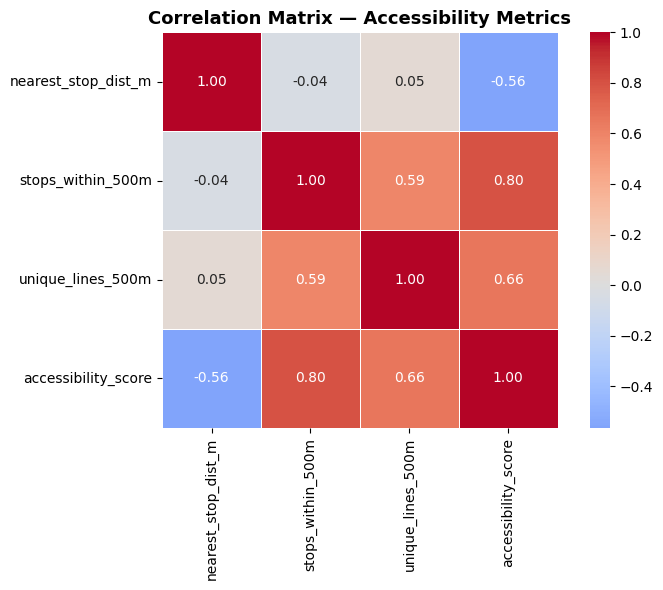

In [65]:
# ── Correlation between accessibility metrics ─────────────────────────────────
corr_cols = ['nearest_stop_dist_m', 'stops_within_500m', 'unique_lines_500m', 'accessibility_score']
corr_matrix = hospitals[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix — Accessibility Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/correlation_matrix.png', bbox_inches='tight')
plt.show()

KeyError: 'facility_type'

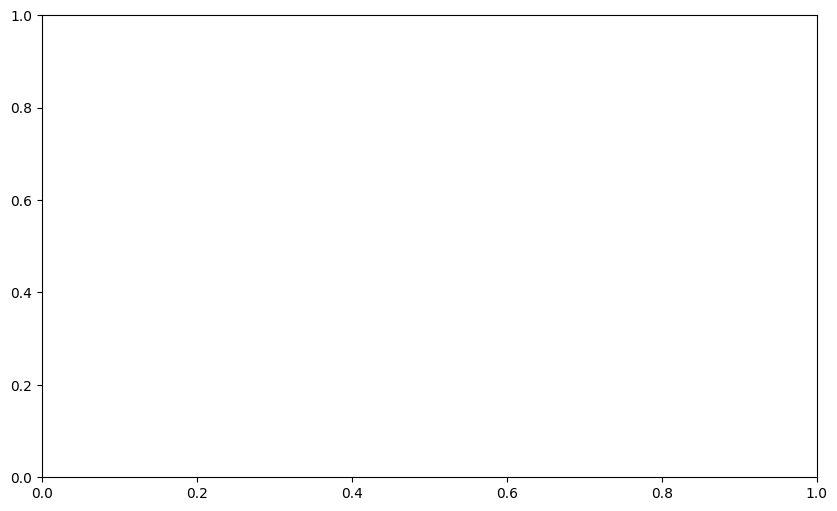

In [ ]:
# # ── Scatter: stops vs score, colored by facility type ────────────────────────
# fig, ax = plt.subplots(figsize=(10, 6))

# for ftype, group in hospitals.groupby('facility_type'):
#     ax.scatter(group['stops_within_500m'], group['accessibility_score'],
#                label=ftype, s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

# ax.set_xlabel('Number of Transport Stops within 500m')
# ax.set_ylabel('Accessibility Score')
# ax.set_title('Transport Stop Density vs. Accessibility Score', fontsize=13, fontweight='bold')
# ax.legend(title='Facility Type', bbox_to_anchor=(1, 1))
# plt.tight_layout()
# plt.savefig(f'{ANALYSIS_OUTPUT_DIR}/scatter_score.png', bbox_inches='tight')
# plt.show()

# Export

In [68]:
# ── Export enriched datasets ──────────────────────────────────────────────────

# Healthcare with all new metrics
export_cols = ['name', 'latitude', 'longitude',
               'nearest_stop_dist_m', 'nearest_stop_name', 'nearest_stop_mode',
               'stops_within_500m', 'unique_lines_500m',
               'accessibility_score', 'access_tier']
hospitals[export_cols].to_csv(f'{ANALYSIS_OUTPUT_DIR}/healthcare_accessibility_results.csv', index=False)

# Transport stops with health facility counts
stops[['stop_name', 'primary_mode', 'num_lines', 'latitude', 'longitude', 'health_facilities_500m']].to_csv(
    f'{ANALYSIS_OUTPUT_DIR}/transport_health_coverage.csv', index=False)

# GeoPackage (preserves geometry)
hospitals.to_file(f'{ANALYSIS_OUTPUT_DIR}/healthcare_accessibility_results.gpkg', driver='GPKG')
stops.to_file(f'{ANALYSIS_OUTPUT_DIR}/transport_health_coverage.gpkg', driver='GPKG')

print('✅ All results exported:')
print('   • healthcare_accessibility_results.csv / .gpkg')
print('   • transport_health_coverage.csv / .gpkg')
print('   • map1_overview.html')
print('   • map2_accessibility.html')
print('   • map3_heatmap.html')

✅ All results exported:
   • healthcare_accessibility_results.csv / .gpkg
   • transport_health_coverage.csv / .gpkg
   • map1_overview.html
   • map2_accessibility.html
   • map3_heatmap.html


---
## 9. Key Findings & Next Steps


### Questions this analysis answers:
- **What % of healthcare facilities are within walkable distance (300–500m) of a transit stop?**
- **Which specific facilities are transit deserts — needing new stops?**
- **Which transit stops are healthcare hubs — serving the most facilities?**

### Suggested next steps:
1. **Isochrone analysis** — use OSRM or Valhalla to compute 15-min transit travel sheds from each stop
2. **Population overlay** — cross with census data to measure how many people are affected by poor access
3. **Route-level analysis** — which bus/tram lines serve the most healthcare facilities?
4. **Time-of-day analysis** — if you have schedule data, assess off-peak accessibility
5. **Equity analysis** — compare accessibility across different neighborhoods/arrondissements

---
*Analysis built with GeoPandas, Folium, scikit-learn. Data: Casablanca Healthcare & Transport Stop datasets.*